### Step 1: Data Exploration (Exploratory Data Analysis - EDA)

To understand the structure of the dataset and how the data behaves, we begin with an initial exploration phase.

During EDA, we perform the following:

- Display the first few rows and inspect important columns
- Check the shape of the dataset and data types
- Identify missing values
- Detect duplicated entries
- Analyze distributions, including outliers or skewed values


FatContent distribution:
FatContent
Low Fat    3668
Regular    2013
Name: count, dtype: int64 

ProductType distribution:
ProductType
Snack Foods              789
Fruits and Vegetables    781
Household                638
Frozen Foods             570
Dairy                    454
Baking Goods             438
Canned                   435
Health and Hygiene       338
Meat                     311
Soft Drinks              281
Breads                   165
Hard Drinks              148
Starchy Foods            121
Others                   111
Breakfast                 76
Seafood                   25
Name: count, dtype: int64 

MRP summary statistics:
count    5681.000000
mean      141.023273
std        61.809091
min        31.990000
25%        94.412000
50%       141.415400
75%       186.026600
max       266.588400
Name: MRP, dtype: float64 

Average MRP by FatContent:
FatContent
Low Fat    141.904357
Regular    139.417801
Name: MRP, dtype: float64 

Average MRP by ProductType:
ProductType
Star

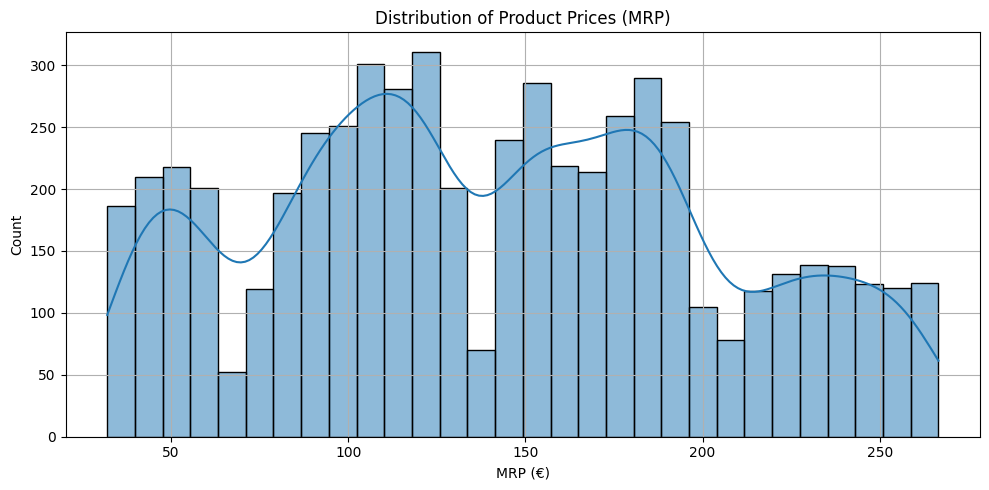

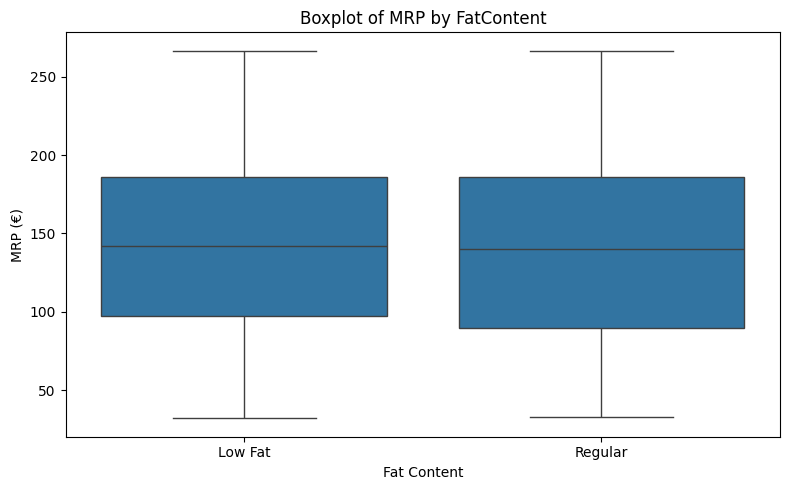

In [6]:
# 🔍 Exploratory Data Analysis (EDA) for Test-Set.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Test-Set.csv")

# Initial cleaning
df['FatContent'] = df['FatContent'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

df['Weight'] = df['Weight'].fillna(df['Weight'].mean())
df['OutletSize'] = df['OutletSize'].fillna(df['OutletSize'].mode()[0])

# --------------------------------------
# Descriptive Statistics
# --------------------------------------

print("FatContent distribution:")
print(df['FatContent'].value_counts(), "\n")

print("ProductType distribution:")
print(df['ProductType'].value_counts(), "\n")

print("MRP summary statistics:")
print(df['MRP'].describe(), "\n")

print("Average MRP by FatContent:")
print(df.groupby('FatContent')['MRP'].mean(), "\n")

print("Average MRP by ProductType:")
print(df.groupby('ProductType')['MRP'].mean().sort_values(ascending=False), "\n")

print("Average Weight by ProductType:")
print(df.groupby('ProductType')['Weight'].mean().sort_values(ascending=False), "\n")

# --------------------------------------
# Visualization
# --------------------------------------

plt.figure(figsize=(10, 5))
sns.histplot(df['MRP'], bins=30, kde=True)
plt.title('Distribution of Product Prices (MRP)')
plt.xlabel('MRP (€)')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='FatContent', y='MRP', data=df)
plt.title('Boxplot of MRP by FatContent')
plt.xlabel('Fat Content')
plt.ylabel('MRP (€)')
plt.tight_layout()
plt.show()


In [ ]:
### Step 3: Univariate & Bivariate Analysis

 **Objective:**
Instead of just listing numbers, we want to deeply understand the structure and behavior of the data.

During this step, we try to answer questions like:

- How is a single feature distributed?
- Are there any relationships or correlations between features?
- Are there patterns, anomalies, or potential opportunities?



In [7]:
# Univariate Analysis - Categorical Columns (No plots)

categorical_columns = ['FatContent', 'ProductType', 'OutletType', 'OutletSize', 'LocationType']

for col in categorical_columns:
    print(f"Column: {col}")
    print("Unique Values and Counts:")
    print(df[col].value_counts())
    print("\nValue Percentages:")
    print(df[col].value_counts(normalize=True) * 100)
    print("-" * 40)



Column: FatContent
Unique Values and Counts:
FatContent
Low Fat    3668
Regular    2013
Name: count, dtype: int64

Value Percentages:
FatContent
Low Fat    64.566098
Regular    35.433902
Name: proportion, dtype: float64
----------------------------------------
Column: ProductType
Unique Values and Counts:
ProductType
Snack Foods              789
Fruits and Vegetables    781
Household                638
Frozen Foods             570
Dairy                    454
Baking Goods             438
Canned                   435
Health and Hygiene       338
Meat                     311
Soft Drinks              281
Breads                   165
Hard Drinks              148
Starchy Foods            121
Others                   111
Breakfast                 76
Seafood                   25
Name: count, dtype: int64

Value Percentages:
ProductType
Snack Foods              13.888400
Fruits and Vegetables    13.747580
Household                11.230417
Frozen Foods             10.033445
Dairy              


🎯 **Objective:**
To summarize and describe the statistical characteristics of numerical columns, and identify anomalies or interesting patterns.

Here we analyze the column: `MRP`

We will examine:

1. Basic descriptive statistics (mean, std, min, max, etc.)
2. Missing values
3. Skewness (distribution symmetry)
4. Range (Max - Min)

This gives us a solid understanding of the numerical behavior of the feature.


In [9]:
# Univariate analysis for numeric column: MRP

# 1. Basic statistics
print("🔸 MRP - Descriptive Statistics:")
print(df['MRP'].describe())
print("-" * 40)

# 2. Missing values
missing = df['MRP'].isnull().sum()
print(f"🔸 Missing values: {missing}")
print("-" * 40)

# 3. Skewness
skewness = df['MRP'].skew()
print(f"🔸 Skewness: {skewness}")
print("-" * 40)

# 4. Range (max - min)
range_mrp = df['MRP'].max() - df['MRP'].min()
print(f"🔸 Range: {range_mrp}")
print("-" * 40)

# 5. Outliers using IQR method
Q1 = df['MRP'].quantile(0.25)
Q3 = df['MRP'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['MRP'] < lower_bound) | (df['MRP'] > upper_bound)]

print(f"🔸 Number of outliers: {len(outliers)}")
print(f"   Lower bound: {lower_bound}")
print(f"   Upper bound: {upper_bound}")
print("-" * 40)


🔸 MRP - Descriptive Statistics:
count    5681.000000
mean      141.023273
std        61.809091
min        31.990000
25%        94.412000
50%       141.415400
75%       186.026600
max       266.588400
Name: MRP, dtype: float64
----------------------------------------
🔸 Missing values: 0
----------------------------------------
🔸 Skewness: 0.13618153880370937
----------------------------------------
🔸 Range: 234.59839999999997
----------------------------------------
🔸 Number of outliers: 0
   Lower bound: -43.00989999999999
   Upper bound: 323.44849999999997
----------------------------------------


#  Top-Priced Product per Outlet Type
# This code identifies the most expensive product (based on MRP) in each OutletType category.
# It groups the dataset by OutletType, finds the top-priced product within each group,
# and displays key information such as ProductID, ProductType, and FatContent.


In [10]:
# Get top priced product(s) per OutletType

top_products = df.sort_values('MRP', ascending=False).groupby('OutletType').first().reset_index()

# Select relevant columns to show
top_products = top_products[['OutletType', 'ProductID', 'MRP', 'ProductType', 'FatContent']]

print(top_products)


          OutletType ProductID       MRP         ProductType FatContent
0      Grocery Store     FDY14  266.2226               Dairy    Low Fat
1  Supermarket Type1     FDR25  266.5884              Canned    Regular
2  Supermarket Type2     NCM05  266.3226  Health and Hygiene    Low Fat
3  Supermarket Type3     FDL58  265.0568         Snack Foods    Regular


#  Analysis: Relationship between MRP and FatContent
# This block analyzes how product prices (MRP) vary based on FatContent type.
# It calculates count, mean, standard deviation, min, and max for each category,
# and helps determine which type is more common and more expensive on average.

In [11]:


import pandas as pd

# Group by FatContent and compute basic statistics for MRP
mrp_stats_by_fat = df.groupby('FatContent')['MRP'].agg(['count', 'mean', 'std', 'min', 'max']).sort_values(by='mean', ascending=False)

# Count number of products in each FatContent category
most_common_fat = df['FatContent'].value_counts()

# Display statistics and counts
print("🔹 MRP statistics by FatContent:\n", mrp_stats_by_fat, "\n")
print("🔹 Product count by FatContent:\n", most_common_fat)


🔹 MRP statistics by FatContent:
             count        mean        std      min       max
FatContent                                                 
Low Fat      3668  141.904357  61.762574  31.9900  266.3226
Regular      2013  139.417801  61.876851  32.7558  266.5884 

🔹 Product count by FatContent:
 FatContent
Low Fat    3668
Regular    2013
Name: count, dtype: int64


In [ ]:
# 🛒 Analysis: Store behavior based on OutletType
# This code analyzes average pricing and product type distribution across different store types.

In [12]:

import pandas as pd

# 1. Average product price (MRP) by OutletType
avg_price_by_outlet = df.groupby('OutletType')['MRP'].agg(['count', 'mean', 'std', 'min', 'max']).sort_values(by='mean', ascending=False)

# 2. Product type distribution within each OutletType (as percentages)
product_distribution = pd.crosstab(df['OutletType'], df['ProductType'], normalize='index') * 100
product_distribution = product_distribution.round(2)

# Show average price table
print("🔹 Average MRP stats by OutletType:\n", avg_price_by_outlet, "\n")

# Show product distribution table
print("🔹 ProductType distribution (%) by OutletType:\n", product_distribution)


🔹 Average MRP stats by OutletType:
                    count        mean        std    min       max
OutletType                                                      
Supermarket Type3    624  142.826241  62.404129  32.39  265.0568
Grocery Store        722  141.960824  61.912419  32.09  266.2226
Supermarket Type1   3717  140.711409  61.913835  31.99  266.5884
Supermarket Type2    618  139.983201  60.542011  32.39  266.3226 

🔹 ProductType distribution (%) by OutletType:
 ProductType        Baking Goods  Breads  Breakfast  Canned  Dairy  \
OutletType                                                          
Grocery Store              7.48    3.46       0.97    8.17   6.79   
Supermarket Type1          7.61    2.91       1.40    7.72   7.96   
Supermarket Type2          8.25    2.91       1.29    6.63   8.25   
Supermarket Type3          8.01    2.24       1.44    7.69   9.29   

ProductType        Frozen Foods  Fruits and Vegetables  Hard Drinks  \
OutletType                             

In [ ]:
#  Rare Products Analysis
# This code finds ProductTypes that appear very few times in the dataset.
# These may be niche or low-demand products worth further investigation . 

In [13]:


# Count the number of occurrences for each ProductType
product_counts = df['ProductType'].value_counts()

# Filter: Find rare products with less than 100 appearances
rare_products = product_counts[product_counts < 100]

# Display the result
print("🔹 Rare Product Types (less than 100 occurrences):\n")
print(rare_products)


🔹 Rare Product Types (less than 100 occurrences):

ProductType
Breakfast    76
Seafood      25
Name: count, dtype: int64
